In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [ ]:
df=pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.drop(['Gender','Age'],axis=1,inplace=True)
df.corr()

,CustomerID,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,0.977548,0.013835
Annual Income (k$),0.977548,1.000000,0.009903
Spending Score (1-100),0.013835,0.009903,1.000000


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


,CustomerID,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,100.500000,60.560000,50.200000
std,57.879185,26.264721,25.823522
min,1.000000,15.000000,1.000000
25%,50.750000,41.500000,34.750000
50%,100.500000,61.500000,50.000000
75%,150.250000,78.000000,73.000000
max,200.000000,137.000000,99.000000


In [ ]:
from sklearn.cluster import KMeans

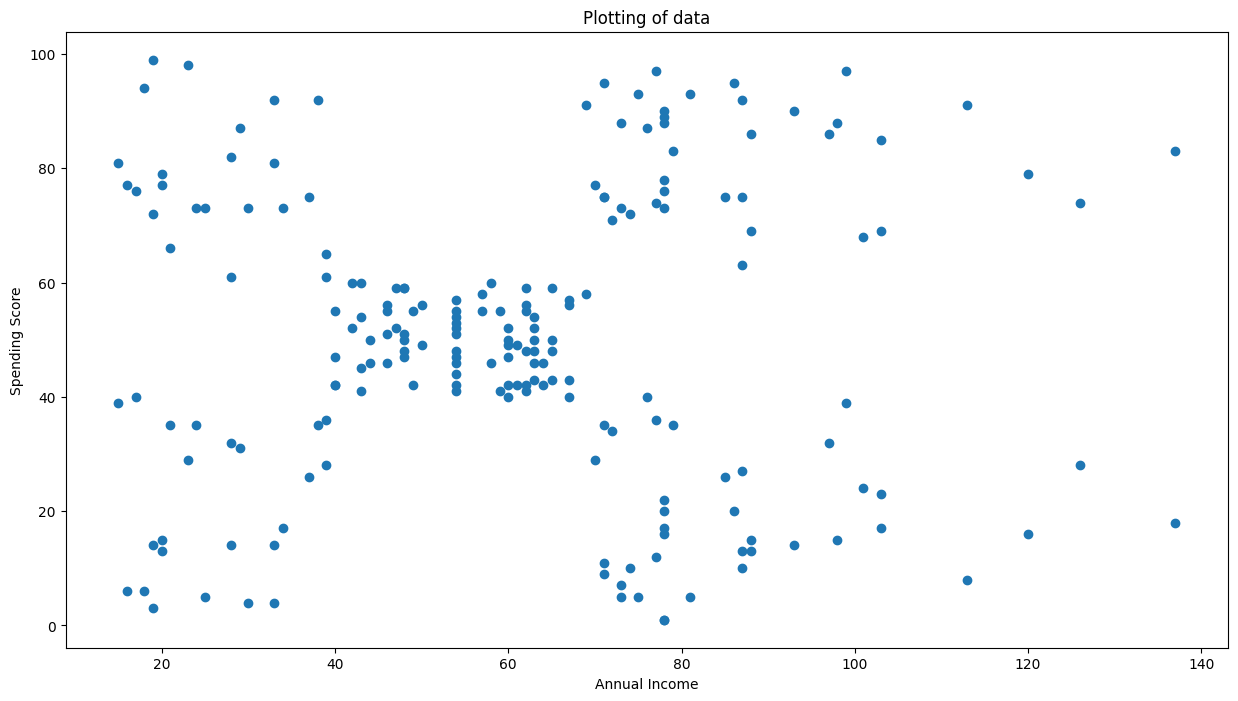

In [ ]:
plt.figure(figsize=(15,8))
plt.scatter(df[:,0],df[:,1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Plotting of data")
plt.show()

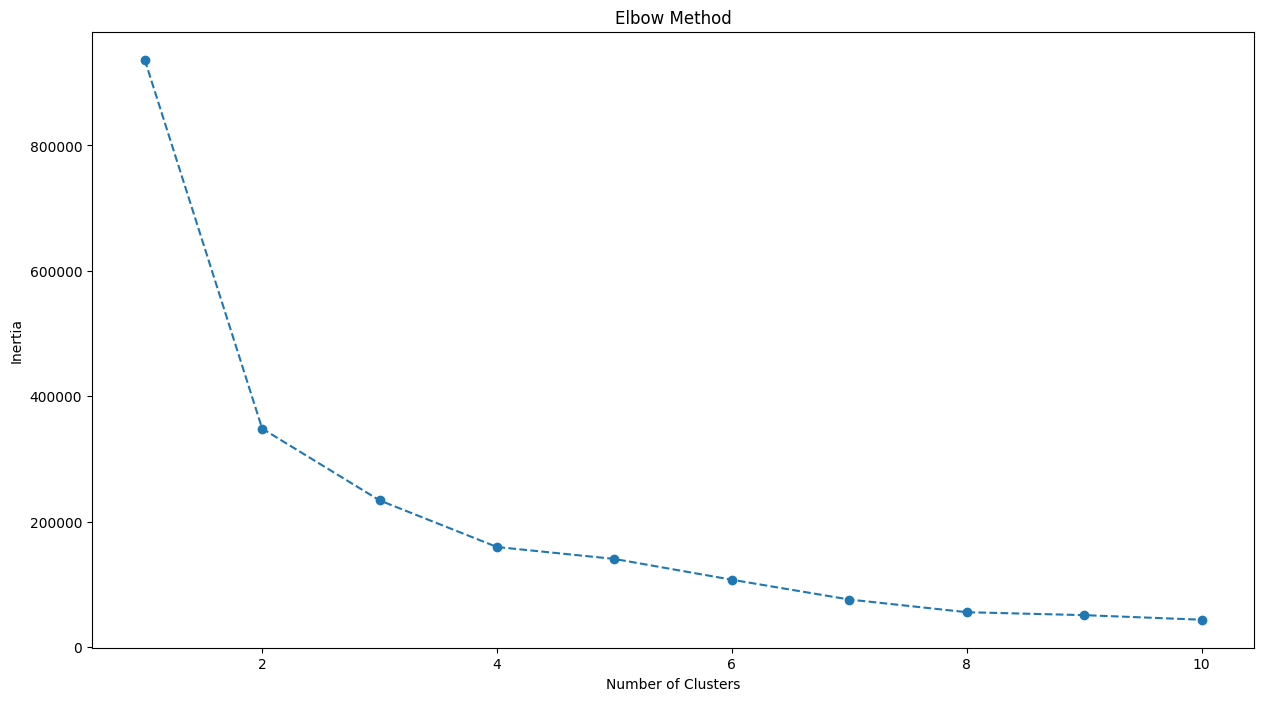

In [ ]:
inertia=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(15,8))
plt.plot(range(1,11),inertia,marker='o',linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=10,random_state=42)
y_pred=kmeans.fit_predict(df)

kmeans.cluster_centers_

array([[ 80.5       ,  53.76923077,  50.38461538],
       [183.        , 100.76470588,  19.52941176],
       [ 22.        ,  25.0952381 ,  80.04761905],
       [165.        ,  82.71428571,  81.07142857],
       [ 20.        ,  24.45      ,  19.1       ],
       [109.09677419,  63.48387097,  48.16129032],
       [145.9       ,  76.1       ,  17.05      ],
       [190.        , 108.18181818,  82.72727273],
       [137.        ,  73.35714286,  82.71428571],
       [ 54.46153846,  43.07692308,  49.92307692]])

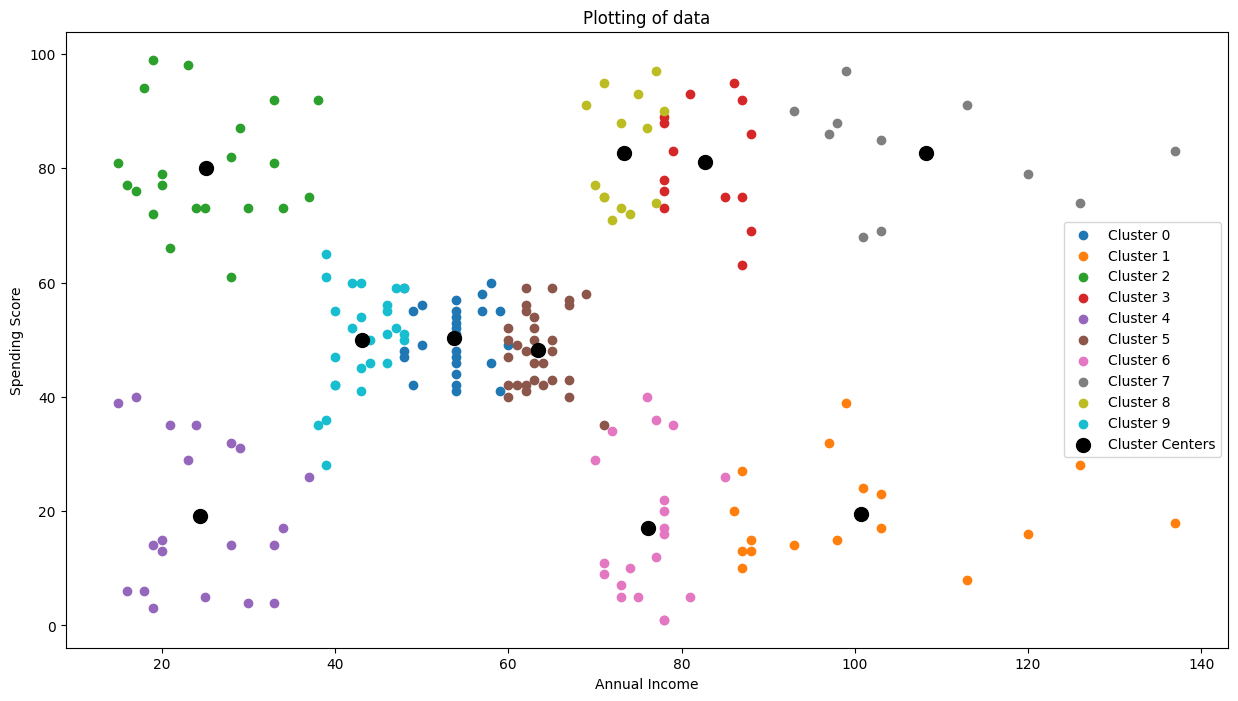

In [ ]:
plt.figure(figsize=(15,8))
# Iterate through unique cluster labels and plot each cluster separately
for cluster_label in np.unique(y_pred):
    plt.scatter(df.loc[y_pred == cluster_label, 'Annual Income (k$)'],
                df.loc[y_pred == cluster_label, 'Spending Score (1-100)'],
                label=f'Cluster {cluster_label}')

# Plot the cluster centers
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2],s=100, c='black', marker='o', label='Cluster Centers')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Plotting of data")
plt.legend() # Add the legend
plt.show()

In [ ]:
# Add the cluster labels to the original DataFrame
df['Cluster'] = y_pred

# Group by cluster and calculate the mean of the relevant features
cluster_characteristics = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Display the characteristics of each cluster
display(cluster_characteristics)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,53.769231,50.384615
1,100.764706,19.529412
2,25.095238,80.047619
3,82.714286,81.071429
4,24.450000,19.100000
5,63.483871,48.161290
6,76.100000,17.050000
7,108.181818,82.727273
8,73.357143,82.714286


In [ ]:
from sklearn.cluster import DBSCAN
from itertools import product

eps_values=np.arange(8,12,0.25)
min_samples=np.arange(3,10)
DBSCAN_params=list(product(eps_values,min_samples))

In [ ]:
from sklearn.metrics import silhouette_score
clusters=[]
sil_score=[]

for p in DBSCAN_params:
  dbscan=DBSCAN(eps=p[0],min_samples=p[1]).fit(df)
  clusters.append(len(np.unique(dbscan.labels_)))
  sil_score.append(silhouette_score(df,dbscan.labels_))


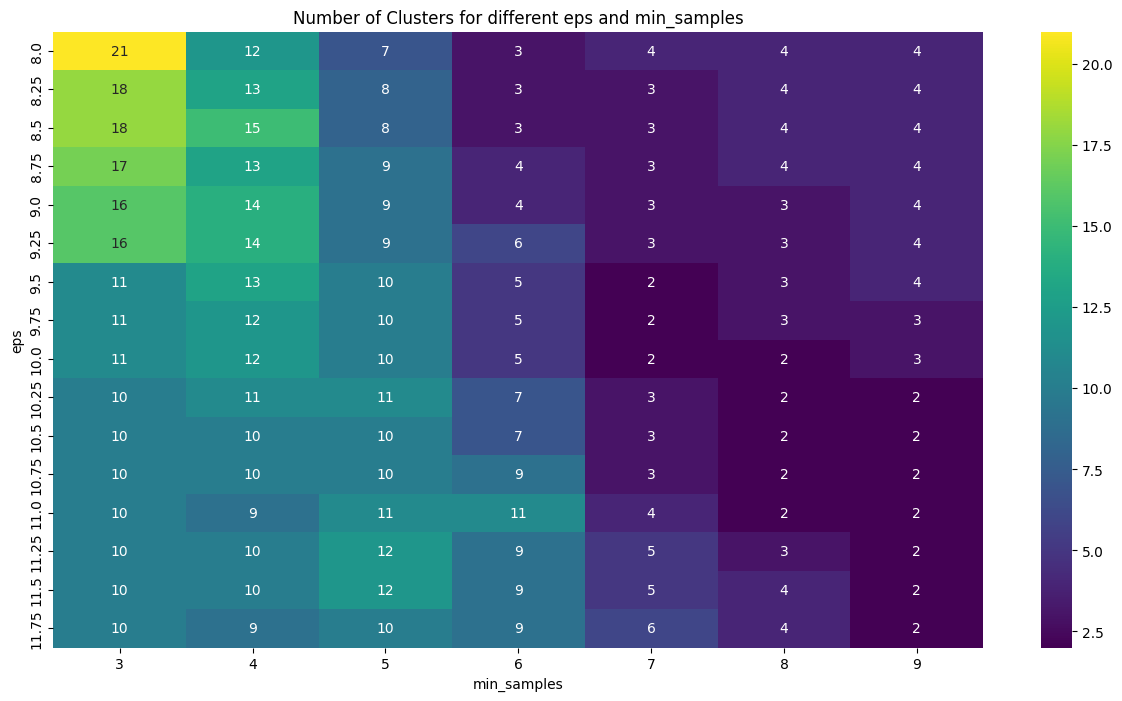

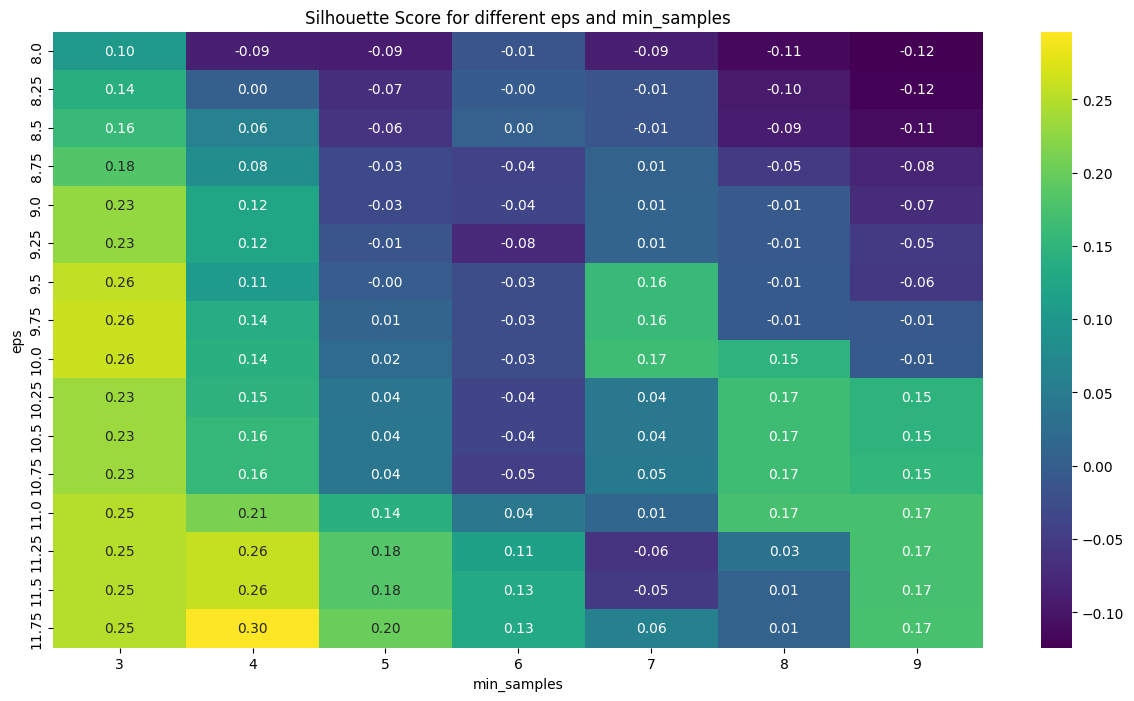

In [ ]:
tmp=pd.DataFrame.from_records(DBSCAN_params,columns=['eps','min_samples'])
tmp['clusters']=clusters
tmp['sil_score']=sil_score # Add silhouette scores to the DataFrame

pivot_1=pd.pivot(tmp,values='clusters',index='eps',columns='min_samples')
pivot_2=pd.pivot(tmp,values='sil_score',index='eps',columns='min_samples')

plt.figure(figsize=(15,8))
sns.heatmap(pivot_1, annot=True, fmt='d', cmap='viridis') # Added annot and fmt for better visualization
plt.title('Number of Clusters for different eps and min_samples')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

plt.figure(figsize=(15,8))
sns.heatmap(pivot_2, annot=True, fmt='.2f', cmap='viridis') # Added annot and fmt for better visualization
plt.title('Silhouette Score for different eps and min_samples')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

In [ ]:
DBS_clustering=DBSCAN(eps=11.75,min_samples=4).fit(df)

DBSCAN_clustered=df.copy()
DBSCAN_clustered.loc[:,'Cluster']=DBS_clustering.labels_

DBSCAN_clust_sizes=DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns=["DBSCAN_size"]
DBSCAN_clust_sizes

,DBSCAN_size
Cluster,
-1,24
0,6
1,17
2,5
3,6
4,86
5,31
6,11
7,14


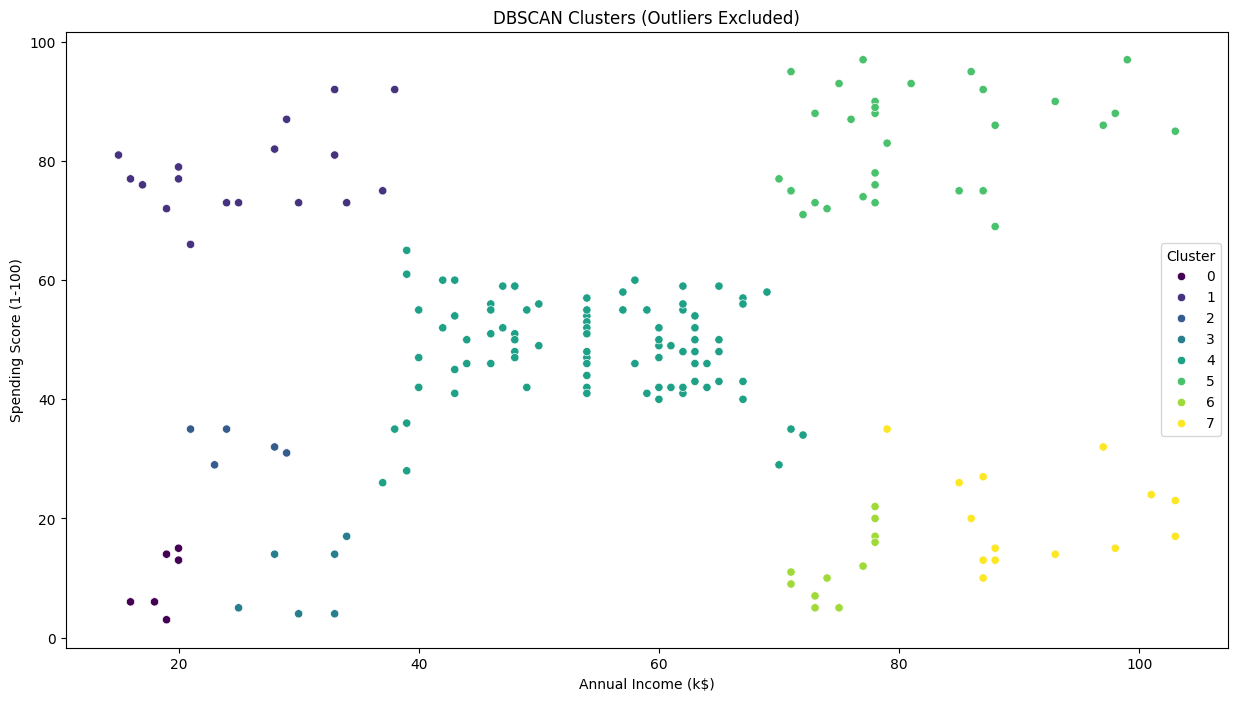

In [ ]:
# Exclude outliers (cluster -1)
clustered_data_excluding_outliers = DBSCAN_clustered[DBSCAN_clustered['Cluster'] != -1]

# Plot the clusters excluding outliers
plt.figure(figsize=(15, 8))
sns.scatterplot(data=clustered_data_excluding_outliers, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', legend='full')

plt.title('DBSCAN Clusters (Outliers Excluded)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()